# Capítulo 5 — Modelos híbridos con Facebook Prophet como regresión

En este notebook se implementa el enfoque híbrido para series de tiempo usando **Facebook Prophet**,




En los capítulos anteriores se exploraron los patrones temporales de la producción agrícola y se ajustaron modelos clásicos como la regresión con errores ARIMA, lo que permitió entender la dinámica de la serie bajo supuestos de estacionariedad. Sin embargo, estos enfoques pueden resultar limitados cuando existen cambios estructurales o comportamientos no lineales que afectan la evolución de la producción en el largo plazo.

En este capítulo incorporamos un enfoque híbrido que combina regresión en series de tiempo con técnicas de aprendizaje estadístico, introduciendo el modelo Facebook Prophet como herramienta de predicción. Prophet permite representar la serie mediante una descomposición aditiva flexible e incluir regresores externos relevantes del conjunto FAOSTAT. Con esto buscamos ampliar las capacidades predictivas del análisis y complementar los modelos estimados previamente.

## Paso 0 — Instalación de Prophet standalone e importación de librerías

In [2]:
!pip uninstall -y prophet pystan cmdstanpy stanpy fbprophet
!pip install prophet[standalone] --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# Configuración básica de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


Found existing installation: prophet 1.1.7
Uninstalling prophet-1.1.7:
  Successfully uninstalled prophet-1.1.7
Found existing installation: cmdstanpy 1.3.0
Uninstalling cmdstanpy-1.3.0:
  Successfully uninstalled cmdstanpy-1.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 1.9 MB/s eta 0:00:00


## Paso 1 — Carga del archivo FAOSTAT desde el equipo

In [3]:
from google.colab import files
import io

print("Selecciona el archivo CSV de FAOSTAT...")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"Archivo cargado: {file_name}")

base = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Primeras filas de la base:")
display(base.head())
print("\nColumnas disponibles:")
print(base.columns.tolist())


Selecciona el archivo CSV de FAOSTAT...


Saving FAOSTAT_Produccion_Agricola_Extendida.csv to FAOSTAT_Produccion_Agricola_Extendida (1).csv
Archivo cargado: FAOSTAT_Produccion_Agricola_Extendida (1).csv
Primeras filas de la base:


,Pais,Producto,Año,Unidad,Produccion,Consumo,Exportaciones,Precio_Promedio_USD
0,Argentina,Coffee,1990,tonnes,9894410,9.276831e+06,2.307871e+06,626.929084
1,Argentina,Coffee,1991,tonnes,8120497,6.840230e+06,2.178363e+06,518.514417
2,Argentina,Coffee,1992,tonnes,2123615,2.462023e+06,3.182868e+05,361.435765
3,Argentina,Coffee,1993,tonnes,3118439,3.525771e+06,7.803743e+05,183.563614
4,Argentina,Coffee,1994,tonnes,6294868,6.204176e+06,5.015579e+05,884.454582



Columnas disponibles:
['Pais', 'Producto', 'Año', 'Unidad', 'Produccion', 'Consumo', 'Exportaciones', 'Precio_Promedio_USD']


## Paso 2 — Preparación y filtrado de datos (incluye Gráfica 1: serie histórica)

Países disponibles:
['Argentina' 'Brazil' 'Chile' 'Colombia' 'Mexico' 'Peru']

Productos disponibles:
['Coffee' 'Maize' 'Rice' 'Soybeans' 'Sugarcane' 'Wheat']
Filas de la serie Colombia - Coffee: 35


,Pais,Producto,Año,Unidad,Produccion,Consumo,Exportaciones,Precio_Promedio_USD
630,Colombia,Coffee,1990,tonnes,7349903,6.101475e+06,1.638504e+06,527.477020
631,Colombia,Coffee,1991,tonnes,2432517,2.834530e+06,4.774724e+05,680.896675
632,Colombia,Coffee,1992,tonnes,8651881,8.229152e+06,9.540534e+05,264.036263
633,Colombia,Coffee,1993,tonnes,6295200,7.438537e+06,1.268758e+06,282.914244
634,Colombia,Coffee,1994,tonnes,4140479,3.390053e+06,4.851321e+05,117.747794


DataFrame listo para Prophet (con regresor escalado):


,ds,y,precio_scaled
0,1990-12-31,7349903.0,0.584240
1,1991-12-31,2432517.0,1.296646
2,1992-12-31,8651881.0,-0.639051
3,1993-12-31,6295200.0,-0.551391
4,1994-12-31,4140479.0,-1.318344


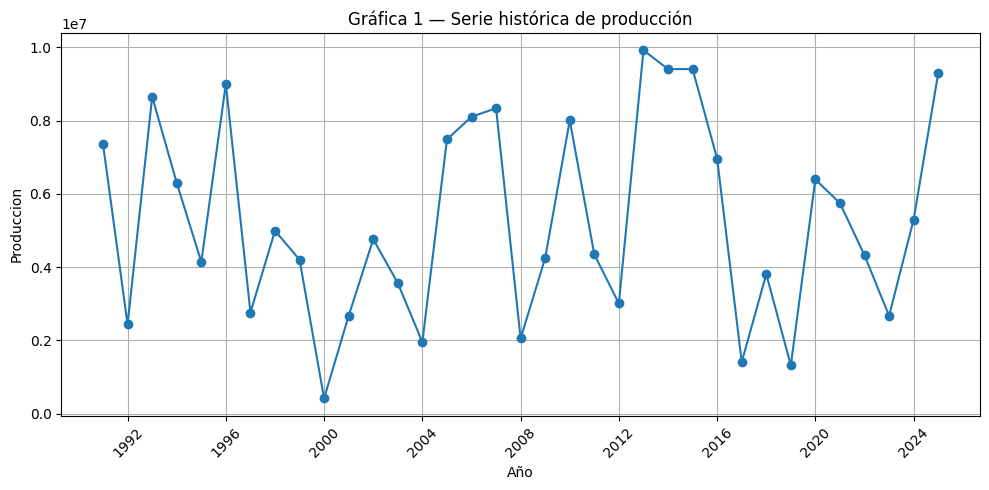

In [4]:
# Configura aquí los nombres de columnas según tu archivo
COUNTRY_COL = 'Pais'
PRODUCT_COL = 'Producto'
YEAR_COL    = 'Año'
TARGET_COL  = 'Produccion'
PRICE_COL   = 'Precio_Promedio_USD'  # regresor externo

print("Países disponibles:")
print(base[COUNTRY_COL].unique())

print("\nProductos disponibles:")
print(base[PRODUCT_COL].unique())

# Selección de país y producto (puedes modificar estos valores)
pais_seleccionado = 'Colombia'
producto_seleccionado = 'Coffee'

serie = base[(base[COUNTRY_COL] == pais_seleccionado) &
             (base[PRODUCT_COL] == producto_seleccionado)].copy()

serie = serie.sort_values(YEAR_COL)

print(f"Filas de la serie {pais_seleccionado} - {producto_seleccionado}: {len(serie)}")
display(serie.head())

# Preparar columnas para Prophet
serie['ds'] = pd.to_datetime(serie[YEAR_COL].astype(str) + "-12-31")
serie['y'] = serie[TARGET_COL].astype(float)

# Crear regresor escalado
if PRICE_COL not in serie.columns:
    raise ValueError(f"No se encontró la columna {PRICE_COL} en la serie. Revisa el nombre de la columna.")

serie['precio_scaled'] = (serie[PRICE_COL] - serie[PRICE_COL].mean()) / serie[PRICE_COL].std()

serie_reg = serie[['ds', 'y', 'precio_scaled']].reset_index(drop=True)

print("DataFrame listo para Prophet (con regresor escalado):")
display(serie_reg.head())

# Gráfica 1: serie histórica
plt.figure()
plt.plot(serie_reg['ds'], serie_reg['y'], marker='o')
plt.title("Gráfica 1 — Serie histórica de producción")
plt.xlabel("Año")
plt.ylabel(TARGET_COL)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Paso 3 — Ajuste de Prophet como modelo de regresión (sin estacionalidad anual)

In [5]:
m_reg = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

m_reg.add_regressor('precio_scaled')

m_reg.fit(serie_reg[['ds', 'y', 'precio_scaled']])


## Paso 4 — Generación del pronóstico a futuro

In [6]:
horizonte = 10  # años hacia adelante

future_reg = m_reg.make_future_dataframe(periods=horizonte, freq='Y')

# Para el futuro, usamos el valor promedio del regresor escalado
future_reg['precio_scaled'] = serie_reg['precio_scaled'].mean()

forecast_reg = m_reg.predict(future_reg)

print("Predicciones (primeras filas):")
display(forecast_reg[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())


Predicciones (primeras filas):


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
0,1990-12-31,5.046578e+06,1.321819e+06,8.293433e+06
1,1991-12-31,5.059971e+06,1.432507e+06,8.365067e+06
2,1992-12-31,5.073400e+06,1.647893e+06,8.863723e+06
3,1993-12-31,5.086793e+06,1.747888e+06,8.465238e+06
4,1994-12-31,5.100185e+06,1.778080e+06,8.380890e+06


## Paso 5 — Gráficas principales del modelo Prophet

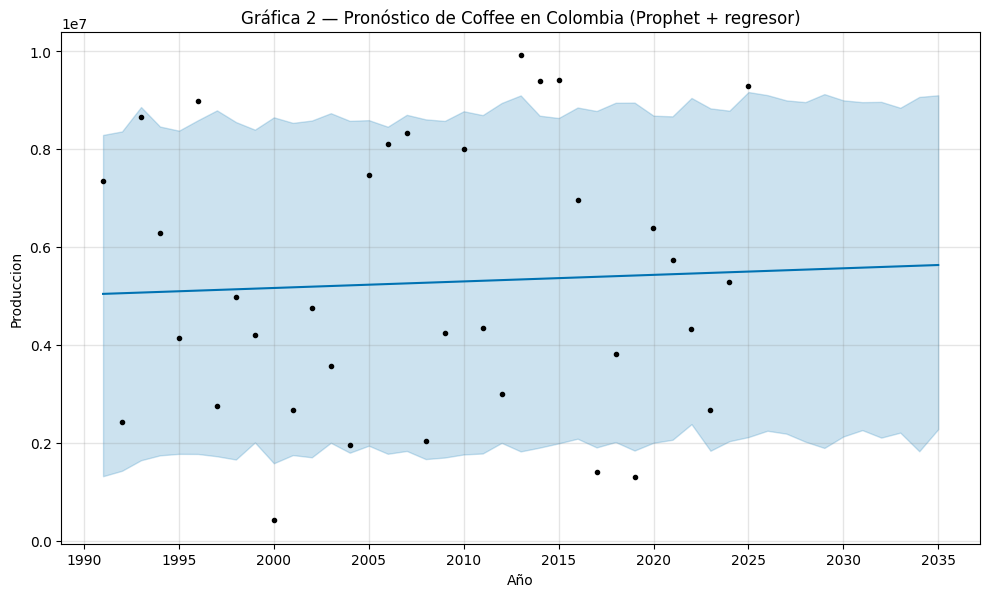

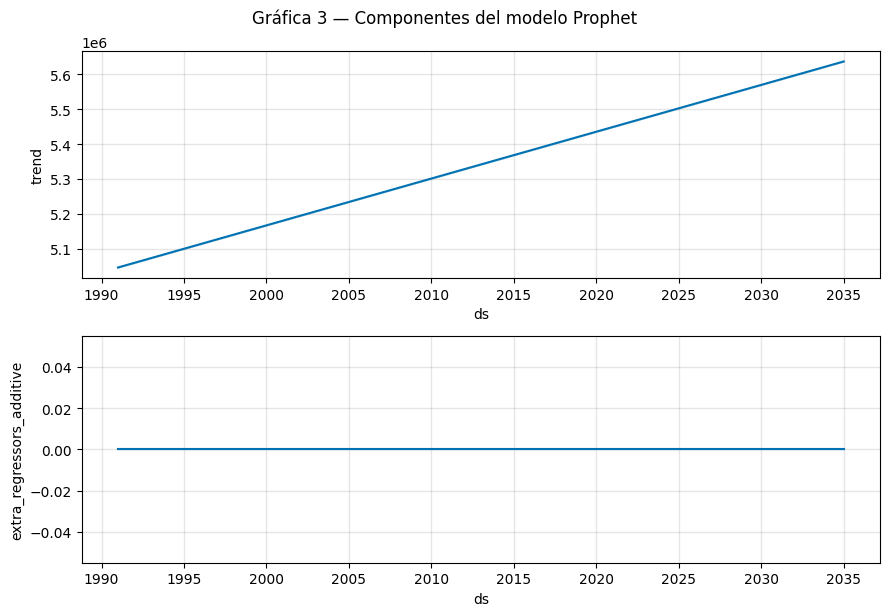

In [7]:
# Gráfica 2: pronóstico general Prophet + regresor
fig = m_reg.plot(forecast_reg)
plt.title(f"Gráfica 2 — Pronóstico de {producto_seleccionado} en {pais_seleccionado} (Prophet + regresor)")
plt.xlabel("Año")
plt.ylabel(TARGET_COL)
plt.show()

# Gráfica 3: componentes del modelo (tendencia + efecto del regresor)
fig2 = m_reg.plot_components(forecast_reg)
plt.suptitle("Gráfica 3 — Componentes del modelo Prophet", y=1.02)
plt.show()


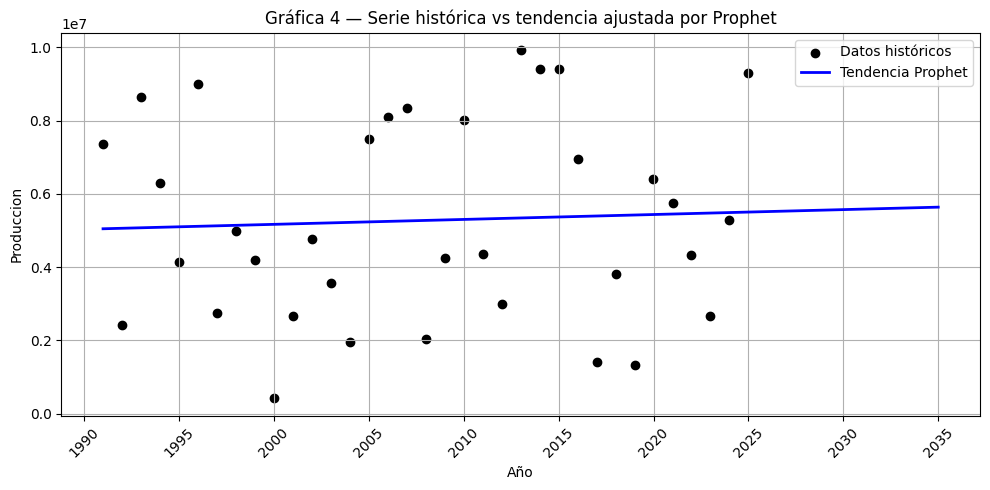

In [8]:
# Gráfica 4: serie histórica vs tendencia ajustada por Prophet

plt.figure()
plt.scatter(serie_reg['ds'], serie_reg['y'], color='black', label='Datos históricos')
plt.plot(forecast_reg['ds'], forecast_reg['trend'], color='blue', linewidth=2, label='Tendencia Prophet')

plt.title("Gráfica 4 — Serie histórica vs tendencia ajustada por Prophet")
plt.xlabel("Año")
plt.ylabel(TARGET_COL)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


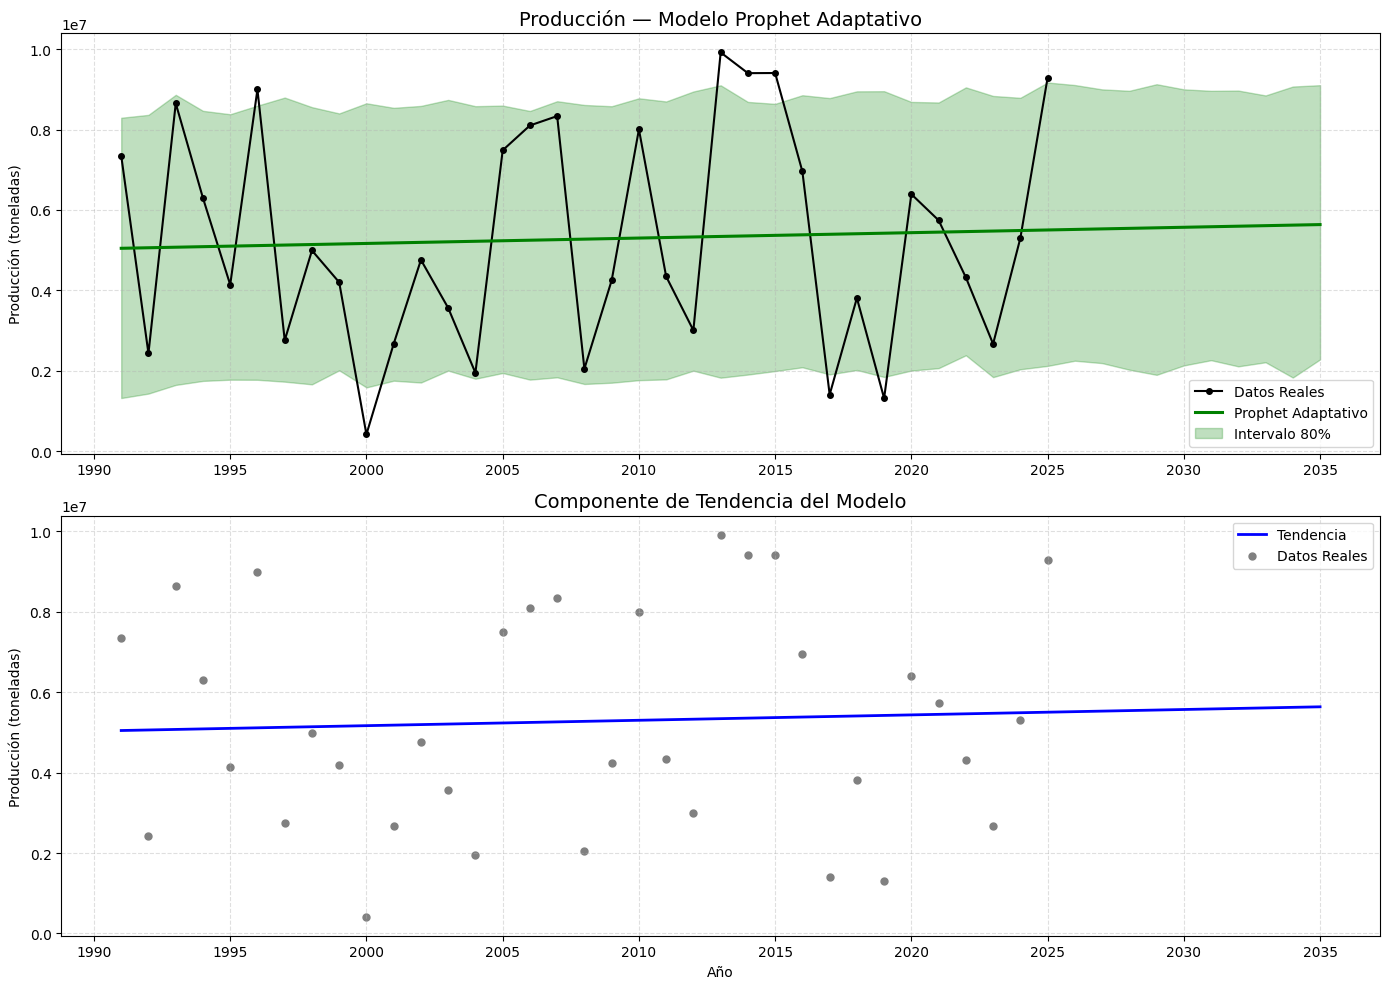

In [9]:
# ======== GRÁFICA PROFESIONAL: AJUSTE + TENDENCIA ========

fig, axs = plt.subplots(2, 1, figsize=(14, 10))
plt.subplots_adjust(hspace=0.35)

# --------------------
# PANEL SUPERIOR — Ajuste del modelo
# --------------------
axs[0].plot(serie_reg['ds'], serie_reg['y'], 'ko-', markersize=4, label='Datos Reales')

# Línea del modelo (yhat)
axs[0].plot(forecast_reg['ds'], forecast_reg['yhat'], color='green', linewidth=2.2, label='Prophet Adaptativo')

# Intervalo 80%
axs[0].fill_between(
    forecast_reg['ds'],
    forecast_reg['yhat_lower'],
    forecast_reg['yhat_upper'],
    color='green',
    alpha=0.25,
    label='Intervalo 80%'
)

axs[0].set_title("Producción — Modelo Prophet Adaptativo", fontsize=14)
axs[0].set_ylabel("Producción (toneladas)")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.4)


# --------------------
# PANEL INFERIOR — Tendencia pura del modelo
# --------------------
axs[1].plot(forecast_reg['ds'], forecast_reg['trend'], color='blue', linewidth=2, label='Tendencia')

# Datos reales como puntos de referencia
axs[1].scatter(serie_reg['ds'], serie_reg['y'], color='gray', s=25, label='Datos Reales')

axs[1].set_title("Componente de Tendencia del Modelo", fontsize=14)
axs[1].set_xlabel("Año")
axs[1].set_ylabel("Producción (toneladas)")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


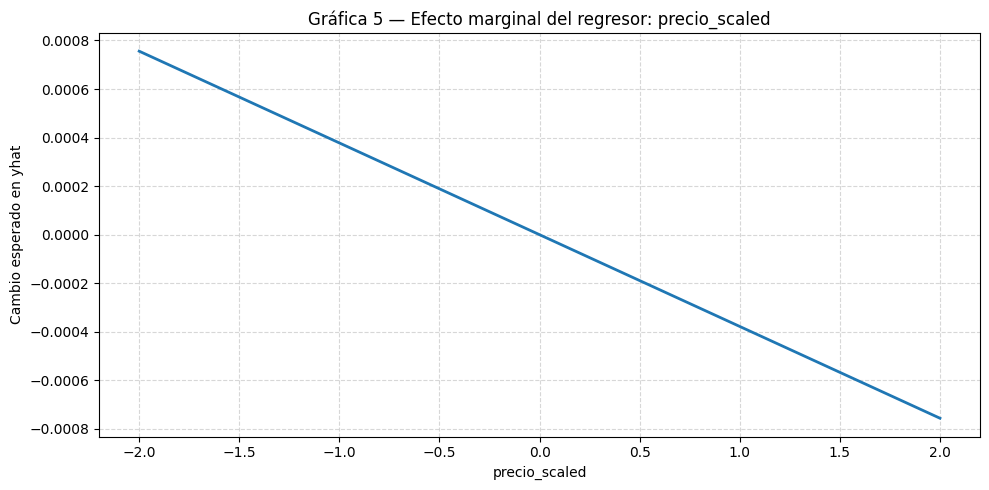

Coeficiente aproximado del regresor (beta): -0.0004


In [10]:
# Gráfica 5: efecto marginal del regresor (precio_scaled) sobre la predicción

# Tomamos el primer coeficiente beta del regresor (único en este caso)
coef = m_reg.params['beta'][0][0]

x_vals = np.linspace(-2, 2, 50)
y_vals = coef * x_vals

plt.figure()
plt.plot(x_vals, y_vals, linewidth=2)
plt.title("Gráfica 5 — Efecto marginal del regresor: precio_scaled")
plt.xlabel("precio_scaled")
plt.ylabel("Cambio esperado en yhat")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Coeficiente aproximado del regresor (beta): {coef:.4f}")


## Paso 6 — Reporte final de predicciones en formato legible

In [11]:
h = 5  # número de años futuros a mostrar en el reporte

forecast_final = forecast_reg[['ds', 'yhat']].tail(h).copy()
forecast_final['Año'] = forecast_final['ds'].dt.year
forecast_final['Predicción'] = forecast_final['yhat'].apply(lambda x: f"{x:,.0f}")

print("\n📈 PREDICCIONES FINALES:\n")
for _, row in forecast_final.iterrows():
    print(f"• {int(row['Año'])}: {row['Predicción']} unidades de {TARGET_COL.lower()}")

print("\n🎯 ANÁLISIS COMPLETADO")
print(f"✔️ {len(serie_reg)} años de datos analizados")
print(f"✔️ {h} años de predicción mostrados en el resumen")



📈 PREDICCIONES FINALES:

• 2030: 5,582,653 unidades de produccion
• 2031: 5,596,045 unidades de produccion
• 2032: 5,609,475 unidades de produccion
• 2033: 5,622,867 unidades de produccion
• 2034: 5,636,260 unidades de produccion

🎯 ANÁLISIS COMPLETADO
✔️ 35 años de datos analizados
✔️ 5 años de predicción mostrados en el resumen


## Paso 7 — Validación cruzada manual (aprendizaje estadístico)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def prophet_manual_cv(df, model_columns, horizon=3, min_train_years=10):
    """
    Validación cruzada manual para Prophet en datos anuales.

    df: DataFrame con columnas 'ds', 'y' y opcionalmente 'precio_scaled'.
    model_columns: columnas que se usan para entrenar (por ejemplo ['ds','y','precio_scaled']).
    horizon: número de años a pronosticar en cada corte.
    min_train_years: número mínimo de años usados para el primer entrenamiento.
    """
    resultados = []
    df = df.sort_values("ds").reset_index(drop=True)
    df['year'] = df['ds'].dt.year
    años = df['year'].unique()

    for corte in range(min_train_years, len(años) - horizon + 1):
        año_corte = años[corte]

        df_train = df[df['year'] < año_corte][model_columns]
        años_test = años[corte : corte + horizon]
        df_test = df[df['year'].isin(años_test)][model_columns]

        if len(df_test) == 0:
            continue

        m_tmp = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False
        )

        if 'precio_scaled' in df.columns:
            m_tmp.add_regressor('precio_scaled')

        m_tmp.fit(df_train)

        if 'precio_scaled' in df.columns:
            future = df_test[['ds', 'precio_scaled']]
        else:
            future = df_test[['ds']]

        pred = m_tmp.predict(future)

        y_true = df_test['y'].values
        y_pred = pred['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        resultados.append({
            "Entrena_hasta": int(df_train['ds'].max().year),
            "Años_test": años_test.tolist(),
            "MAE": mae,
            "RMSE": rmse
        })

    return pd.DataFrame(resultados)


print("⏳ Ejecutando validación cruzada manual...")

df_cv_manual = prophet_manual_cv(
    df=serie_reg,
    model_columns=['ds', 'y', 'precio_scaled'],
    horizon=3,
    min_train_years=10
)

print("✔️ Validación cruzada completada")
display(df_cv_manual)


INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 8.


⏳ Ejecutando validación cruzada manual...


INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 16.
INFO:prophet:n_changepoints greater than number of observations. Using 17.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoint

✔️ Validación cruzada completada


,Entrena_hasta,Años_test,MAE,RMSE
0,1999,"[2000, 2001, 2002]",1.488516e+06,1.628440e+06
1,2000,"[2001, 2002, 2003]",1.647947e+06,1.811499e+06
2,2001,"[2002, 2003, 2004]",2.788235e+06,3.835022e+06
3,2002,"[2003, 2004, 2005]",4.230673e+06,4.934535e+06
4,2003,"[2004, 2005, 2006]",6.460445e+06,6.481270e+06
5,2004,"[2005, 2006, 2007]",3.709686e+06,4.212783e+06
6,2005,"[2006, 2007, 2008]",2.291442e+06,2.844152e+06
7,2006,"[2007, 2008, 2009]",2.402586e+06,2.576560e+06
8,2007,"[2008, 2009, 2010]",1.287620e+06,2.093357e+06
9,2008,"[2009, 2010, 2011]",1.636661e+06,2.224636e+06


## Paso 8 — Gráfica 6: RMSE por corte de validación

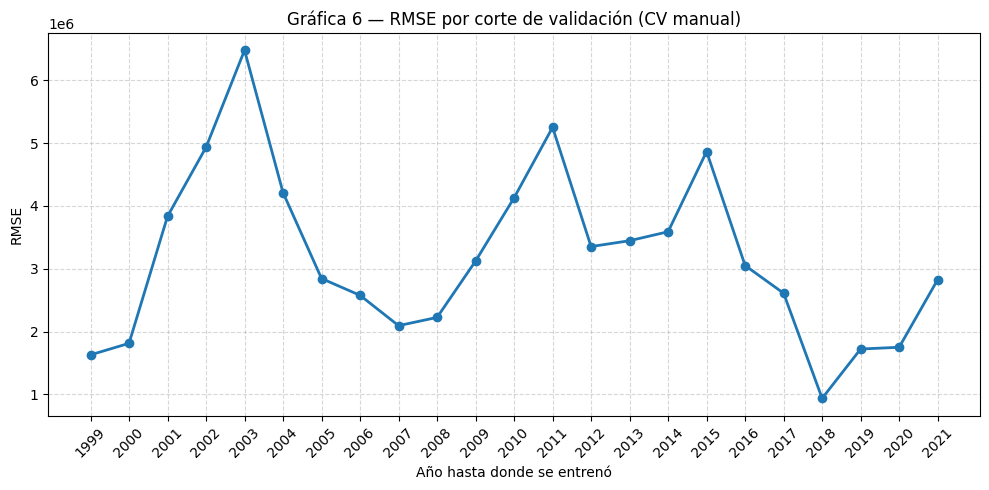

In [13]:
plt.figure()
plt.plot(df_cv_manual['Entrena_hasta'], df_cv_manual['RMSE'],
         marker='o', linestyle='-', linewidth=2)

plt.title("Gráfica 6 — RMSE por corte de validación (CV manual)")
plt.xlabel("Año hasta donde se entrenó")
plt.ylabel("RMSE")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(df_cv_manual['Entrena_hasta'], rotation=45)
plt.tight_layout()
plt.show()


## Paso 9 (opcional) — Escenarios de cambio en el regresor (+10% y -10%)

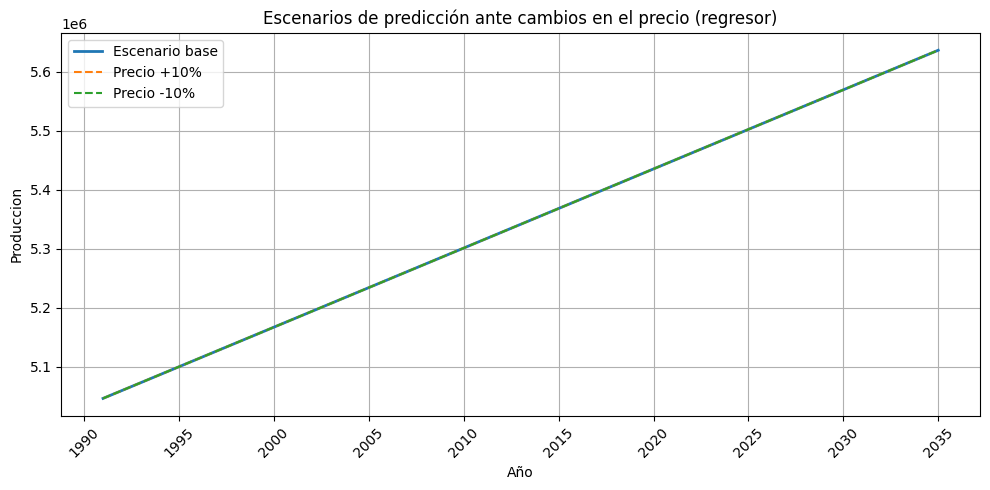

In [14]:
# Escenarios de sensibilidad al regresor (precio_scaled)

future_hi = future_reg.copy()
future_lo = future_reg.copy()

future_hi['precio_scaled'] = future_hi['precio_scaled'] * 1.10  # +10%
future_lo['precio_scaled'] = future_lo['precio_scaled'] * 0.90  # -10%

pred_hi = m_reg.predict(future_hi)
pred_lo = m_reg.predict(future_lo)

plt.figure()
plt.plot(forecast_reg['ds'], forecast_reg['yhat'], label="Escenario base", linewidth=2)
plt.plot(pred_hi['ds'], pred_hi['yhat'], '--', label="Precio +10%")
plt.plot(pred_lo['ds'], pred_lo['yhat'], '--', label="Precio -10%")

plt.title("Escenarios de predicción ante cambios en el precio (regresor)")
plt.xlabel("Año")
plt.ylabel(TARGET_COL)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
